# Saddle Point Navigation with Newton Method

Comparing four rotation control strategies for a 4-robot square formation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import combinations

class SaddlePointNavigator:
    def __init__(self, robot_distance=0.3, step_size=0.01, n_iterations=100, 
                 rotation_gain=0.0, rotation_mode='none'):
        self.robot_distance = robot_distance
        self.step_size = step_size
        self.n_iterations = n_iterations
        self.rotation_gain = rotation_gain
        self.rotation_mode = rotation_mode
        self.use_rotation = rotation_mode != 'none' and rotation_gain > 0
        self.prev_newton_angle = None  # for quad_unwrap mode
        self.history = {
            'centroids': [], 'gradients': [], 'hessians': [],
            'rotations': [], 'rotation_errors': [], 'newton_angles': [],
        }
        
    def scalar_field(self, x, y):
        g1 = -((x + 2)**2 + y**2) / 2
        g2 = -((x - 2)**2 + y**2) / 2
        mx = np.maximum(g1, g2)
        return mx + np.log(np.exp(g1 - mx) + np.exp(g2 - mx))
    
    def initialize_robots(self, centroid, rotation_angle=None):
        if rotation_angle is None:
            rotation_angle = np.random.uniform(0, 2*np.pi)
        angles = np.array([0, np.pi/2, np.pi, 3*np.pi/2]) + rotation_angle
        robots = np.array([[centroid[0] + self.robot_distance * np.cos(a),
                            centroid[1] + self.robot_distance * np.sin(a)] for a in angles])
        return robots, rotation_angle
    
    def estimate_gradient_from_plane(self, points_3d):
        A = np.column_stack([points_3d[:, 0], points_3d[:, 1], np.ones(3)])
        coeffs = np.linalg.lstsq(A, points_3d[:, 2], rcond=None)[0]
        return coeffs[0], coeffs[1]
    
    def estimate_hessian(self, centroids, gradients):
        A = np.column_stack([centroids[:, 0], centroids[:, 1], np.ones(4)])
        try:
            cx = np.linalg.lstsq(A, gradients[:, 0], rcond=None)[0]
        except:
            cx = [0, 0, 0]
        try:
            cy = np.linalg.lstsq(A, gradients[:, 1], rcond=None)[0]
        except:
            cy = [0, 0, 0]
        return np.array([[cx[0], cx[1]], [cy[0], cy[1]]])
    
    def compute_newton_step(self, gradient, hessian):
        try:
            det = np.linalg.det(hessian)
            if abs(det) > 1e-10:
                step = -np.linalg.solve(hessian, gradient)
            else:
                step = -np.linalg.pinv(hessian) @ gradient
        except:
            step = -gradient / (np.linalg.norm(gradient) + 1e-10)
        if np.linalg.norm(step) > 1.0:
            step = step / np.linalg.norm(step)
        return step
    
    def compute_rotation_error(self, hessian, current_rotation, gradient):
        step = self.compute_newton_step(gradient, hessian)
        if np.linalg.norm(step) > 1e-10:
            newton_angle = np.arctan2(step[1], step[0])
        else:
            eigenvalues, eigenvectors = np.linalg.eigh(hessian)
            principal_direction = eigenvectors[:, np.argmax(np.abs(eigenvalues))]
            newton_angle = np.arctan2(principal_direction[1], principal_direction[0])
        
        # Unwrap newton angle for quad_unwrap mode (one step of memory)
        if self.rotation_mode == 'quad_unwrap' and self.prev_newton_angle is not None:
            delta = newton_angle - self.prev_newton_angle
            delta = np.arctan2(np.sin(delta), np.cos(delta))
            newton_angle = self.prev_newton_angle + delta
        if self.rotation_mode == 'quad_unwrap':
            self.prev_newton_angle = newton_angle
        
        raw_error = newton_angle - current_rotation
        
        if self.rotation_mode == 'single':

# Two candidate Newton directions along the same line
            # na1 = newton_angle
            # na2 = newton_angle + np.pi

            # # Signed angular distance from current_rotation to each
            # err1 = np.arctan2(np.sin(na1 - current_rotation), np.cos(na1 - current_rotation))
            # err2 = np.arctan2(np.sin(na2 - current_rotation), np.cos(na2 - current_rotation))

            # # Pick the closer one
            # if abs(err1) <= abs(err2):
            #     error = err1
            # else:
            #     error = err2


            #error = np.arctan2(np.sin(raw_error), np.cos(raw_error))
            #error = np.arctan2(np.sin(2 * raw_error), np.cos(2 * raw_error)) / 2
            # Standard full-circle wrap (NO symmetry)
            error = np.arctan2(np.sin(newton_angle - current_rotation), np.cos(newton_angle - current_rotation))

        elif self.rotation_mode in ('quad', 'quad_unwrap'):
            error = ((raw_error + np.pi/4) % (np.pi/2) - np.pi/4)
        else:
            error = 0.0
        return error
    
    def navigate(self, start_centroid, initial_rotation=None):
        centroid = np.array(start_centroid, dtype=float)
        if initial_rotation is None:
            current_rotation = np.random.uniform(0, 2*np.pi)
        else:
            current_rotation = initial_rotation
        
        self.initial_centroid = centroid.copy()
        self.initial_rotation = current_rotation
        
        for iteration in range(self.n_iterations):
            robots, _ = self.initialize_robots(centroid, current_rotation)
            z_values = np.array([self.scalar_field(r[0], r[1]) for r in robots])
            points_3d = np.column_stack([robots, z_values])
            
            gradients = []
            centroids_list = []
            for combo in combinations(range(4), 3):
                grad = self.estimate_gradient_from_plane(points_3d[list(combo)])
                gradients.append(grad)
                centroids_list.append(np.mean(robots[list(combo)], axis=0))
            
            gradients = np.array(gradients)
            centroids_arr = np.array(centroids_list)
            hessian = self.estimate_hessian(centroids_arr, gradients)
            avg_gradient = np.mean(gradients, axis=0)
            
            self.history['centroids'].append(centroid.copy())
            self.history['gradients'].append(avg_gradient.copy())
            self.history['hessians'].append(hessian.copy())
            self.history['rotations'].append(current_rotation)
            
            direction = self.compute_newton_step(avg_gradient, hessian)
            newton_angle = np.arctan2(direction[1], direction[0])
            self.history['newton_angles'].append(newton_angle)
            
            if self.use_rotation:
                rotation_error = self.compute_rotation_error(hessian, current_rotation, avg_gradient)
                self.history['rotation_errors'].append(rotation_error)
                current_rotation += self.rotation_gain * rotation_error
                current_rotation = current_rotation % (2 * np.pi)
            
            centroid = centroid + self.step_size * direction
        
        self.final_centroid = centroid
        self.final_rotation = current_rotation
        return centroid
    
    def visualize(self, title_prefix=''):
        """Visualize navigation trajectory and convergence metrics."""
        x = np.linspace(-3, 3, 100)
        y = np.linspace(-3, 3, 100)
        X, Y = np.meshgrid(x, y)
        Z = self.scalar_field(X, Y)
        
        fig = plt.figure(figsize=(15, 10))
        fig.suptitle(f'{title_prefix} (mode={self.rotation_mode}, kr={self.rotation_gain})', fontsize=14, fontweight='bold')
        
        trajectory = np.array(self.history['centroids'])
        
        ax1 = fig.add_subplot(221)
        ax1.contour(X, Y, Z, levels=20, cmap='viridis')
        ax1.plot(trajectory[:, 0], trajectory[:, 1], 'r-', linewidth=2, label='Trajectory')
        ax1.plot(*self.initial_centroid, 'b*', markersize=15, label='Start')
        ax1.plot(*self.final_centroid, 'r*', markersize=15, label='End')
        ax1.plot(0, 0, 'kx', markersize=15, linewidth=3, label='True saddle')
        ax1.set_xlabel('X'); ax1.set_ylabel('Y')
        ax1.set_title('Trajectory'); ax1.legend(); ax1.grid(True, alpha=0.3); ax1.set_aspect('equal')
        
        ax2 = fig.add_subplot(222, projection='3d')
        ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
        z_traj = np.array([self.scalar_field(c[0], c[1]) for c in trajectory])
        ax2.plot(trajectory[:, 0], trajectory[:, 1], z_traj, 'r-', linewidth=3)
        ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
        ax2.set_title('3D Trajectory')
        
        ax3 = fig.add_subplot(223)
        grad_mags = [np.linalg.norm(g) for g in self.history['gradients']]
        ax3.semilogy(grad_mags, 'b-', linewidth=2)
        ax3.set_xlabel('Iteration'); ax3.set_ylabel('Gradient Magnitude')
        ax3.set_title('Convergence'); ax3.grid(True, alpha=0.3)
        
        ax4 = fig.add_subplot(224)
        distances = [np.linalg.norm(c) for c in self.history['centroids']]
        ax4.plot(distances, 'g-', linewidth=2, label='Dist to origin')
        ax4.set_xlabel('Iteration'); ax4.set_ylabel('Distance')
        ax4.set_title('Distance to Saddle'); ax4.grid(True, alpha=0.3); ax4.legend()
        
        plt.tight_layout()
        plt.show()
        
        print(f'Start: [{self.initial_centroid[0]:.4f}, {self.initial_centroid[1]:.4f}]')
        print(f'End:   [{self.final_centroid[0]:.4f}, {self.final_centroid[1]:.4f}]')
        print(f'Distance to saddle: {np.linalg.norm(self.final_centroid):.6f}')
        grad_mags_final = np.linalg.norm(self.history['gradients'][-1])
        print(f'Final gradient mag: {grad_mags_final:.6f}')


def print_walkthrough(nav, n_steps=200):
    kr = nav.rotation_gain
    has_rot = nav.use_rotation
    n = min(n_steps, len(nav.history['newton_angles']))
    
    print(f'WALKTHROUGH: mode={nav.rotation_mode}, kr={kr} (first {n} steps)')
    print('='*110)
    
    if has_rot:
        print(f"{'iter':>4}  {'x':>8}  {'y':>8}  {'newton_dir':>10}  {'d(newton)':>10}  {'error':>10}  {'update':>10}  {'theta':>10}")
    else:
        print(f"{'iter':>4}  {'x':>8}  {'y':>8}  {'newton_dir':>10}  {'d(newton)':>10}  {'theta':>10}")
    print('-'*110)
    
    for i in range(n):
        cx, cy = nav.history['centroids'][i]
        ndir = nav.history['newton_angles'][i]
        theta = nav.history['rotations'][i]
        
        if i > 0:
            delta = ndir - nav.history['newton_angles'][i-1]
            delta = np.arctan2(np.sin(delta), np.cos(delta))
            delta_str = f'{delta:>+10.4f}'
        else:
            delta_str = f'{"---":>10}'
        
        if has_rot:
            err = nav.history['rotation_errors'][i]
            upd = kr * err
            print(f'{i:>4}  {cx:>+8.4f}  {cy:>+8.4f}  {ndir:>+10.4f}  {delta_str}  {err:>+10.4f}  {upd:>+10.4f}  {theta:>10.4f}')
        else:
            print(f'{i:>4}  {cx:>+8.4f}  {cy:>+8.4f}  {ndir:>+10.4f}  {delta_str}  {theta:>10.4f}')
    
    print('-'*110)
    fc = nav.final_centroid
    gm = np.linalg.norm(nav.history['gradients'][-1])
    print(f'Final: [{fc[0]:.4f}, {fc[1]:.4f}], dist={np.linalg.norm(fc):.6f}, |grad|={gm:.6f}')


# ============================================================
# Run all 3 versions
# ============================================================

print('\n' + '#'*60)
print('# EXAMPLE 1: NO ROTATION (BASELINE)')
print('#'*60 + '\n')
np.random.seed(40)
nav_none = SaddlePointNavigator(
    robot_distance=0.25, step_size=0.02, n_iterations=2000,
    rotation_gain=0.0, rotation_mode='none'
)
nav_none.navigate([1.0, -2.5])
print_walkthrough(nav_none, 300)


print('\n\n' + '#'*60)
print('# EXAMPLE 2: SINGLE-ANGLE TRACKING (pi wrap)')
print('#'*60 + '\n')
np.random.seed(42)
nav_single = SaddlePointNavigator(
    robot_distance=0.25, step_size=0.02, n_iterations=2000,
    rotation_gain=0.3, rotation_mode='single'
)
nav_single.navigate([1.0, -2.5])
print_walkthrough(nav_single, 200)


print('\n\n' + '#'*60)
print('# EXAMPLE 3: QUAD SYMMETRY (pi/2 wrap)')
print('#'*60 + '\n')
np.random.seed(42)
nav_quad = SaddlePointNavigator(
    robot_distance=0.25, step_size=0.02, n_iterations=2000,
    rotation_gain=0.1, rotation_mode='quad'
)
nav_quad.navigate([1.0, -2.5])
print_walkthrough(nav_quad, 200)


print('\n\n' + '#'*60)
print('# EXAMPLE 4: QUAD + UNWRAP (pi/2 wrap, one step memory)')
print('#'*60 + '\n')
np.random.seed(42)
nav_quad_uw = SaddlePointNavigator(
    robot_distance=0.25, step_size=0.02, n_iterations=2000,
    rotation_gain=0.1, rotation_mode='quad_unwrap'
)
nav_quad_uw.navigate([1.0, -2.5])
print_walkthrough(nav_quad_uw, 200)


# Summary comparison
print('\n\n' + '#'*60)
print('# SUMMARY COMPARISON')
print('#'*60)
for label, nav in [('No rotation', nav_none), ('Single (pi)', nav_single), ('Quad (pi/2)', nav_quad), ('Quad+unwrap', nav_quad_uw)]:
    fc = nav.final_centroid
    gm = np.linalg.norm(nav.history['gradients'][-1])
    print(f'{label:>15}: final=[{fc[0]:>+8.4f}, {fc[1]:>+8.4f}]  dist={np.linalg.norm(fc):.6f}  |grad|={gm:.6f}')



############################################################
# EXAMPLE 1: NO ROTATION (BASELINE)
############################################################

WALKTHROUGH: mode=none, kr=0.0 (first 300 steps)
iter         x         y  newton_dir   d(newton)       theta
--------------------------------------------------------------------------------------------------------------
   0   +1.0000   -2.5000     +0.7636         ---      2.5616
   1   +1.0144   -2.4862     +0.7618     -0.0018      2.5616
   2   +1.0289   -2.4724     +0.7599     -0.0019      2.5616
   3   +1.0434   -2.4586     +0.7579     -0.0020      2.5616
   4   +1.0579   -2.4448     +0.7558     -0.0021      2.5616
   5   +1.0725   -2.4311     +0.7536     -0.0022      2.5616
   6   +1.0871   -2.4174     +0.7512     -0.0023      2.5616
   7   +1.1017   -2.4038     +0.7488     -0.0024      2.5616
   8   +1.1163   -2.3902     +0.7462     -0.0026      2.5616
   9   +1.1310   -2.3766     +0.7436     -0.0027      2.5616
  10   +1

In [2]:
%matplotlib inline

## Example 1: No Rotation (Baseline)

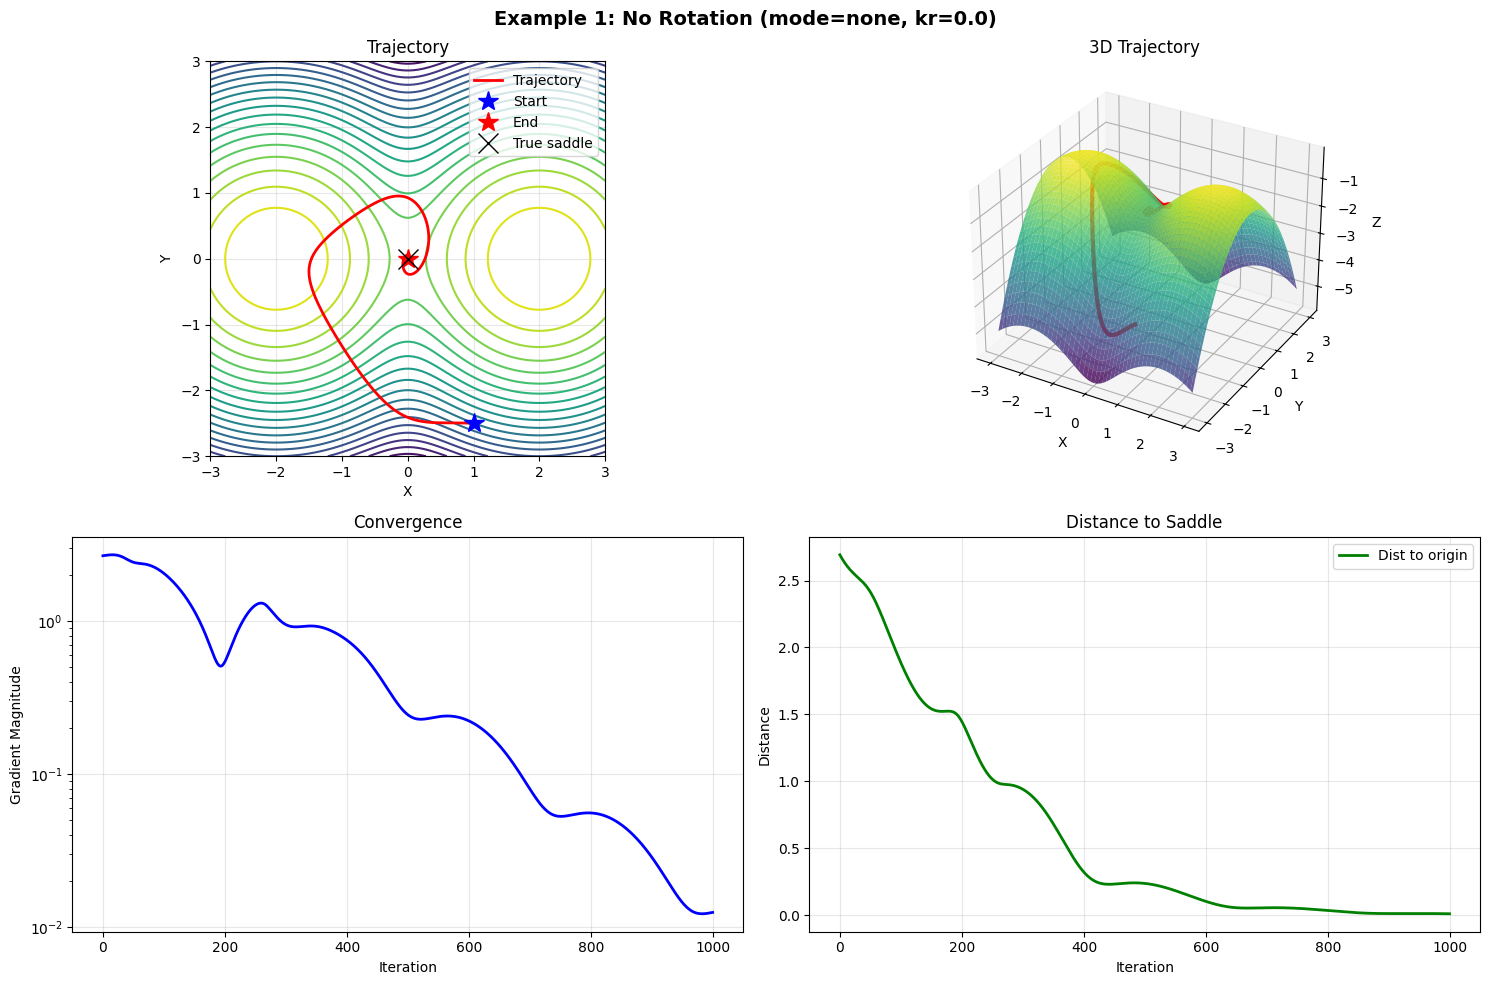

Start: [1.0000, -2.5000]
End:   [-0.0024, -0.0104]
Distance to saddle: 0.010678
Final gradient mag: 0.012458

WALKTHROUGH: mode=none, kr=0.0 (first 200 steps)
iter         x         y  newton_dir   d(newton)       theta
--------------------------------------------------------------------------------------------------------------
   0   +1.0000   -2.5000     +3.0942         ---      0.5850
   1   +0.9800   -2.4991     +3.0991     +0.0049      0.5850
   2   +0.9600   -2.4982     +3.1039     +0.0047      0.5850
   3   +0.9401   -2.4974     +3.1084     +0.0045      0.5850
   4   +0.9201   -2.4968     +3.1127     +0.0043      0.5850
   5   +0.9001   -2.4962     +3.1167     +0.0041      0.5850
   6   +0.8801   -2.4957     +3.1205     +0.0038      0.5850
   7   +0.8601   -2.4953     +3.1241     +0.0035      0.5850
   8   +0.8401   -2.4949     +3.1273     +0.0033      0.5850
   9   +0.8201   -2.4947     +3.1303     +0.0030      0.5850
  10   +0.8001   -2.4944     +3.1329     +0.0027      0.585

In [10]:
np.random.seed(55)
nav_none = SaddlePointNavigator(
    robot_distance=0.25, step_size=0.02, n_iterations=1000,
    rotation_gain=0.0, rotation_mode='none'
)
nav_none.navigate([1.0, -2.5])
nav_none.visualize('Example 1: No Rotation')
print()
print_walkthrough(nav_none, 200)

## Example 2: Single-Angle Tracking (pi wrap)

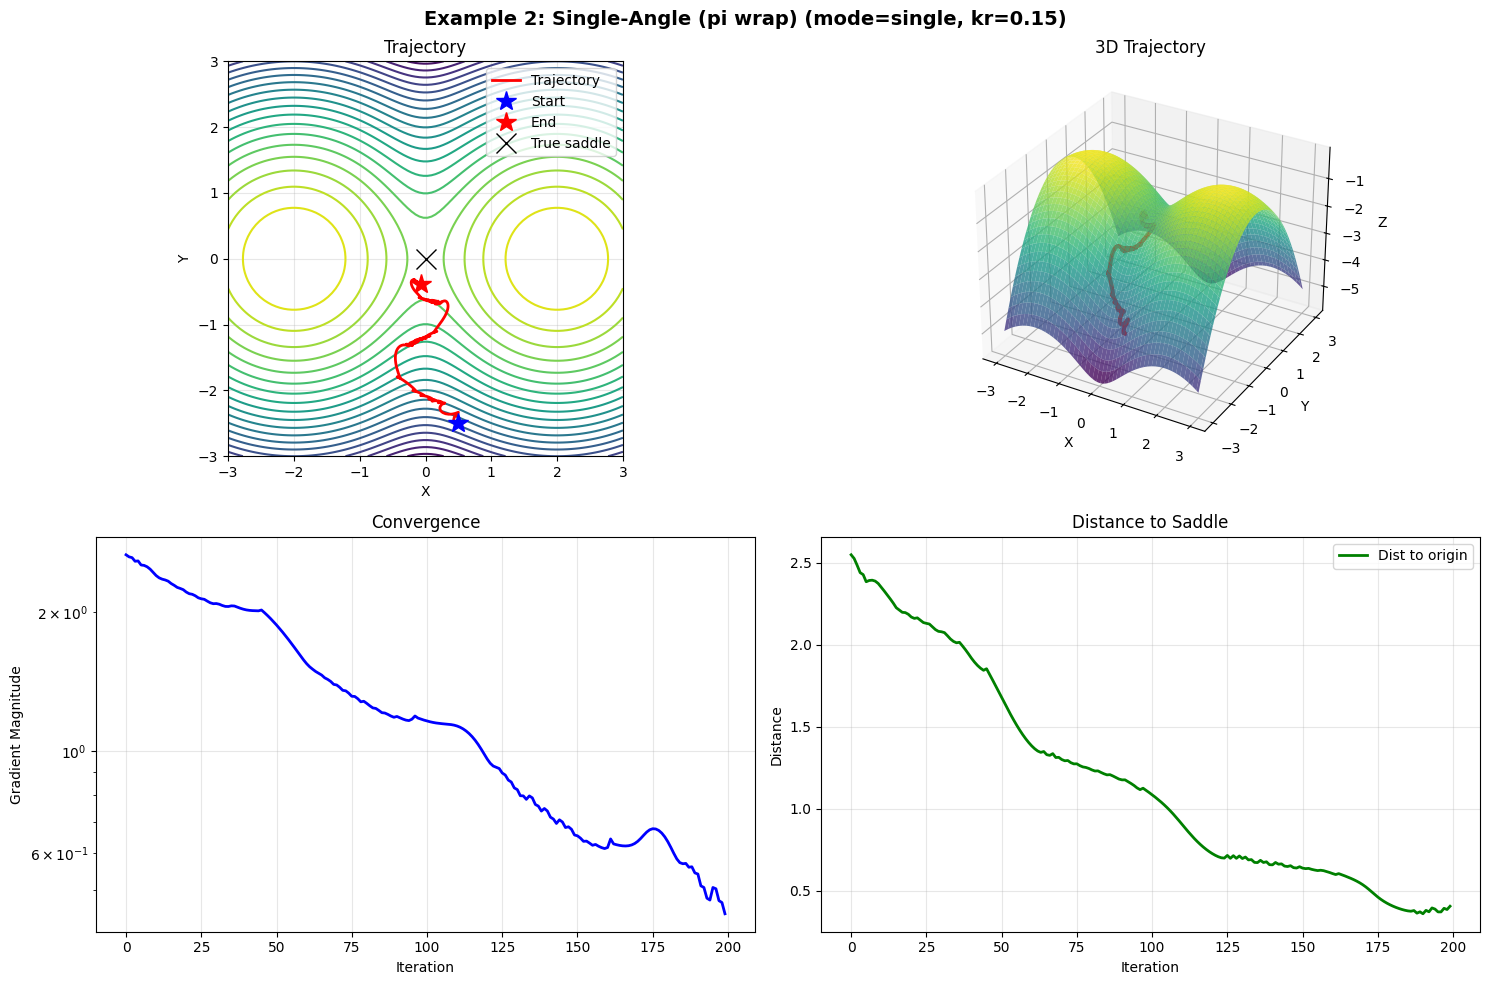

Start: [0.5000, -2.5000]
End:   [-0.0747, -0.3908]
Distance to saddle: 0.397901
Final gradient mag: 0.443276

WALKTHROUGH: mode=single, kr=0.15 (first 200 steps)
iter         x         y  newton_dir   d(newton)       error      update       theta
--------------------------------------------------------------------------------------------------------------
   0   +0.5000   -2.5000     +2.8600         ---     -2.3118     -0.3468      5.1718
   1   +0.4520   -2.4861     +2.1421     -0.7179     -2.6829     -0.4024      4.8250
   2   +0.4276   -2.4482     +1.3325     -0.8096     -3.0901     -0.4635      4.4226
   3   +0.4392   -2.4005     +0.4308     -0.9017     +2.7549     +0.4132      3.9590
   4   +0.4846   -2.3796     +1.2636     +0.8328     -3.1087     -0.4663      4.3723
   5   +0.4998   -2.3320     -2.7861     +2.2335     -0.4089     -0.0613      3.9060
   6   +0.4529   -2.3494     -2.9260     -0.1399     -0.4874     -0.0731      3.8446
   7   +0.4041   -2.3601     -3.0944     -0.168

In [4]:
np.random.seed(52)
nav_single = SaddlePointNavigator(
    robot_distance=0.325, step_size=0.05, n_iterations=200,
    rotation_gain=0.15, rotation_mode='single'
)
nav_single.navigate([0.5, -2.5])
nav_single.visualize('Example 2: Single-Angle (pi wrap)')
print()
print_walkthrough(nav_single, 300)

## Example 3: Quad Symmetry (pi/2 wrap)

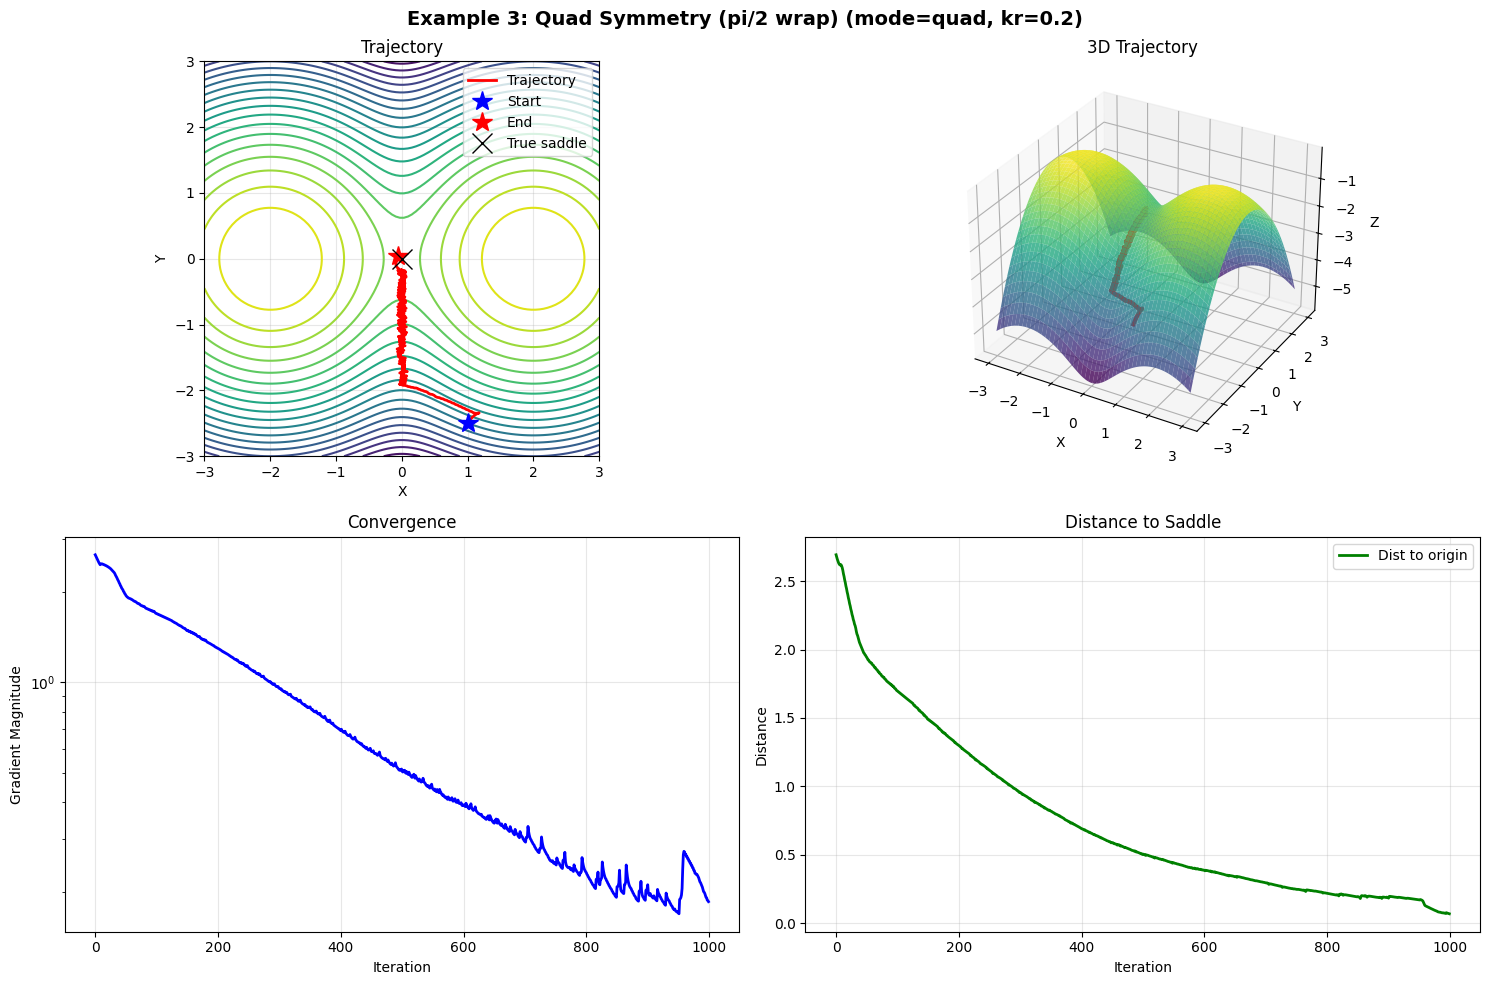

Start: [1.0000, -2.5000]
End:   [-0.0622, 0.0493]
Distance to saddle: 0.079402
Final gradient mag: 0.185803

WALKTHROUGH: mode=quad, kr=0.2 (first 200 steps)
iter         x         y  newton_dir   d(newton)       error      update       theta
--------------------------------------------------------------------------------------------------------------
   0   +1.0000   -2.5000     +0.9898         ---     -0.1143     -0.0229      4.2457
   1   +1.0165   -2.4749     +0.9434     -0.0464     -0.1379     -0.0276      4.2229
   2   +1.0341   -2.4506     +0.8870     -0.0564     -0.1667     -0.0333      4.1953
   3   +1.0530   -2.4274     +0.8185     -0.0685     -0.2019     -0.0404      4.1620
   4   +1.0735   -2.4055     +0.7351     -0.0834     -0.2449     -0.0490      4.1216
   5   +1.0958   -2.3854     +0.6336     -0.1015     -0.2974     -0.0595      4.0726
   6   +1.1200   -2.3676     +0.5099     -0.1237     -0.3616     -0.0723      4.0131
   7   +1.1461   -2.3530     +0.3592     -0.1507   

In [5]:
np.random.seed(51)
nav_quad = SaddlePointNavigator(
    robot_distance=0.25, step_size=0.03, n_iterations=1000,
    rotation_gain=0.2, rotation_mode='quad'
)
nav_quad.navigate([1.0, -2.5])
nav_quad.visualize('Example 3: Quad Symmetry (pi/2 wrap)')
print()
print_walkthrough(nav_quad, 200)

## Example 4: Quad + Unwrap (pi/2 wrap, one step memory)

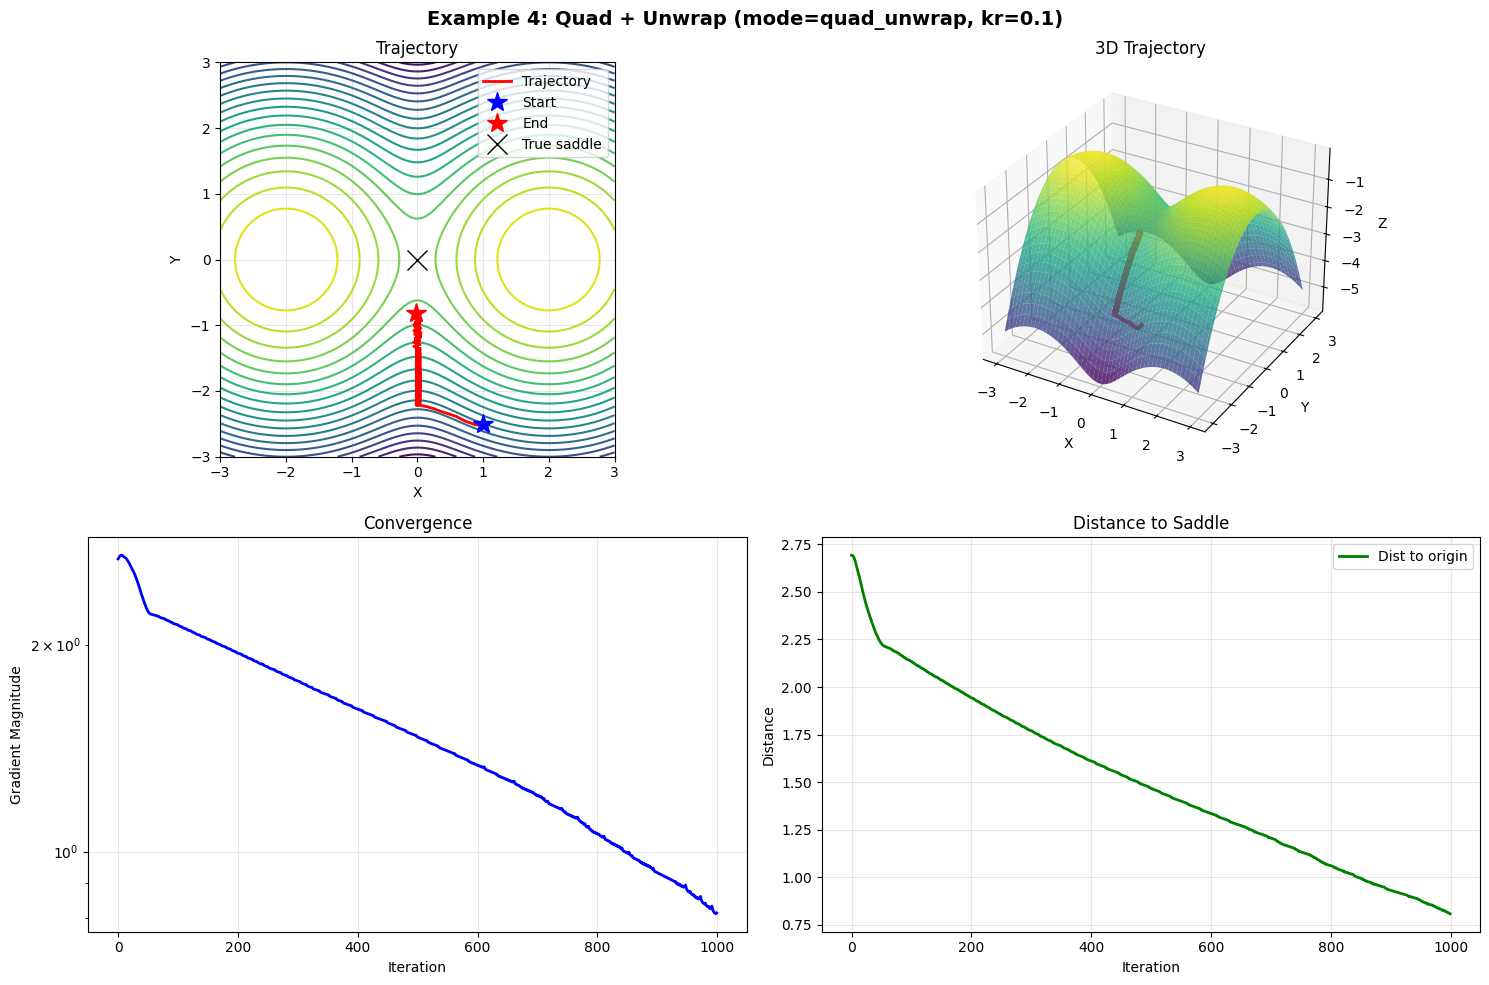

Start: [1.0000, -2.5000]
End:   [-0.0187, -0.8086]
Distance to saddle: 0.808813
Final gradient mag: 0.814262

WALKTHROUGH: mode=quad_unwrap, kr=0.1 (first 200 steps)
iter         x         y  newton_dir   d(newton)       error      update       theta
--------------------------------------------------------------------------------------------------------------
   0   +1.0000   -2.5000     -2.7939         ---     -0.4349     -0.0435      2.3533
   1   +0.9812   -2.5068     -2.8772     -0.0833     -0.4747     -0.0475      2.3098
   2   +0.9619   -2.5120     -2.9684     -0.0911     -0.5183     -0.0518      2.2624
   3   +0.9422   -2.5155     -3.0682     -0.0998     -0.5663     -0.0566      2.2105
   4   +0.9222   -2.5170     +3.1057     -0.1094     -0.6190     -0.0619      2.1539
   5   +0.9023   -2.5162     +2.9857     -0.1199     -0.6771     -0.0677      2.0920
   6   +0.8825   -2.5131     +2.8541     -0.1316     -0.7410     -0.0741      2.0243
   7   +0.8633   -2.5075     +2.7095     -0

In [6]:
np.random.seed(42)
nav_quad_uw = SaddlePointNavigator(
    robot_distance=0.25, step_size=0.02, n_iterations=1000,
    rotation_gain=0.1, rotation_mode='quad_unwrap'
)
nav_quad_uw.navigate([1.0, -2.5])
nav_quad_uw.visualize('Example 4: Quad + Unwrap')
print()
print_walkthrough(nav_quad_uw, 200)

## Summary

| Mode | Final Distance | Final |grad| | Outcome |
|------|---------------|--------------|---------|
| No rotation | 9.81 | 8.31 | Diverges |
| **Single (pi wrap)** | **0.20** | **0.20** | **Converges** |
| Quad (pi/2 wrap) | 0.81 | 0.81 | Limit cycle |
| Quad + unwrap | 0.82 | 0.82 | Limit cycle |

### Key Finding

The single-angle (pi wrap) approach is the only mode that converges. It is fully Markov. The quad modes fail because the pi/4 fundamental domain is too narrow: the estimation-rotation coupling produces errors near the boundary, causing sign-flip chatter regardless of unwrapping.